# Сравнение букмекеров как baseline

Цель: сравнить качество прогнозов разных букмекеров (PS, B365, Max, Avg) как baseline моделей.

Гипотеза: букмекеры с низким overround (Max) могут быть лучшим baseline.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

## 1. Подготовка данных

In [2]:
import re

def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", "", parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()

def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", "", parts[0])
    init = re.sub(r"[^a-z]", "", parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()

ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(ods, how='inner', on=['week', 'p1', 'p2'], suffixes=('_tml', '_ods'))
print('joined shape:', joined.shape)

joined shape: (17633, 99)


In [3]:
# Build target
joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

# Available bookmakers columns
bookmaker_cols = {
    'PS': ('PSW', 'PSL'),
    'B365': ('B365W', 'B365L'),
    'BFE': ('BFEW', 'BFEL'),
    'LB': ('LBW', 'LBL'),
    'EX': ('EXW', 'EXL'),
}

# Check which bookmakers are available
available = {}
for name, (w_col, l_col) in bookmaker_cols.items():
    if w_col in joined.columns and l_col in joined.columns:
        available[name] = (w_col, l_col)
        print(f'{name}: available')
    else:
        print(f'{name}: NOT available')

# Check Max and Avg (aggregated columns)
if 'MaxW' in joined.columns and 'MaxL' in joined.columns:
    available['Max'] = ('MaxW', 'MaxL')
    print('Max: available')
if 'AvgW' in joined.columns and 'AvgL' in joined.columns:
    available['Avg'] = ('AvgW', 'AvgL')
    print('Avg: available')

PS: available
B365: available
BFE: available
LB: available
EX: available
Max: available
Avg: available


In [4]:
# Compute implied probabilities for each bookmaker
for name, (w_col, l_col) in available.items():
    # odds for p1/p2
    joined[f'{name}_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined[w_col], joined[l_col])
    joined[f'{name}_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined[w_col], joined[l_col])
    
    # implied probability (normalized)
    p1 = 1.0 / joined[f'{name}_odds_p1']
    p2 = 1.0 / joined[f'{name}_odds_p2']
    s = p1 + p2
    joined[f'{name}_imp_p1'] = p1 / s

print('Implied probabilities computed')

Implied probabilities computed


## 2. Coverage by bookmaker

In [5]:
print('=== Coverage by bookmaker ===')
for name in available.keys():
    col = f'{name}_imp_p1'
    n_valid = joined[col].notna().sum()
    pct = n_valid / len(joined) * 100
    print(f'{name}: {n_valid} ({pct:.1f}%)')

=== Coverage by bookmaker ===
PS: 17477 (99.1%)
B365: 17562 (99.6%)
BFE: 294 (1.7%)
LB: 3831 (21.7%)
EX: 4483 (25.4%)
Max: 17619 (99.9%)
Avg: 17619 (99.9%)


## 3. Сравнение качества на test (2024+)

In [6]:
# Time-based split
cutoff = pd.Timestamp('2024-01-01')
test_df = joined[joined['week'] >= cutoff].copy()
y_test = test_df['y_p1_win']

print(f'test size: {len(test_df)}')

test size: 3535


In [7]:
def eval_baseline(y_true, p_pred, name):
    mask = np.isfinite(p_pred) & np.isfinite(y_true)
    if mask.sum() == 0:
        return None  # Skip bookmakers with no valid samples
    y = y_true[mask].astype(int)
    p = p_pred[mask].clip(1e-6, 1-1e-6)
    return {
        'bookmaker': name,
        'n': len(y),
        'logloss': log_loss(y, p),
        'roc_auc': roc_auc_score(y, p),
        'acc@0.5': accuracy_score(y, p >= 0.5),
    }

results = []
for name in available.keys():
    col = f'{name}_imp_p1'
    if col in test_df.columns:
        p = test_df[col].to_numpy()
        res = eval_baseline(y_test, p, name)
        if res is not None:
            results.append(res)

results_df = pd.DataFrame(results).sort_values('logloss')
print('=== Baseline comparison (test 2024+) ===')
print(results_df)

=== Baseline comparison (test 2024+) ===
  bookmaker     n   logloss   roc_auc   acc@0.5
2       BFE   294  0.575565  0.770875  0.683673
1      B365  3526  0.596467  0.742969  0.677538
3       Max  3532  0.596545  0.742870  0.679219
4       Avg  3532  0.596857  0.742608  0.677237
0        PS  3448  0.598630  0.740271  0.675754


## 4. Сравнение по годам (walk-forward style)

In [8]:
cutoffs = ['2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01']

all_results = []
for cutoff in cutoffs:
    cutoff_ts = pd.Timestamp(cutoff)
    test_df = joined[joined['week'] >= cutoff_ts].copy()
    y_test = test_df['y_p1_win']
    
    for name in available.keys():
        col = f'{name}_imp_p1'
        if col in test_df.columns:
            p = test_df[col].to_numpy()
            res = eval_baseline(y_test, p, name)
            if res is not None:
                res['cutoff'] = cutoff
                all_results.append(res)

all_results_df = pd.DataFrame(all_results)
print('=== Results by cutoff ===')
print(all_results_df.pivot_table(index='bookmaker', columns='cutoff', values='logloss').round(4))

=== Results by cutoff ===
cutoff     2019-01-01  2020-01-01  2021-01-01  2022-01-01  2023-01-01  \
bookmaker                                                               
Avg            0.5903      0.5890      0.5899      0.5899      0.5946   
B365           0.5908      0.5895      0.5900      0.5891      0.5943   
BFE            0.5756      0.5756      0.5756      0.5756      0.5756   
Max            0.5894      0.5881      0.5890      0.5887      0.5940   
PS             0.5894      0.5883      0.5892      0.5895      0.5950   

cutoff     2024-01-01  2025-01-01  
bookmaker                          
Avg            0.5969      0.6043  
B365           0.5965      0.6039  
BFE            0.5756      0.5756  
Max            0.5965      0.6046  
PS             0.5986      0.6084  


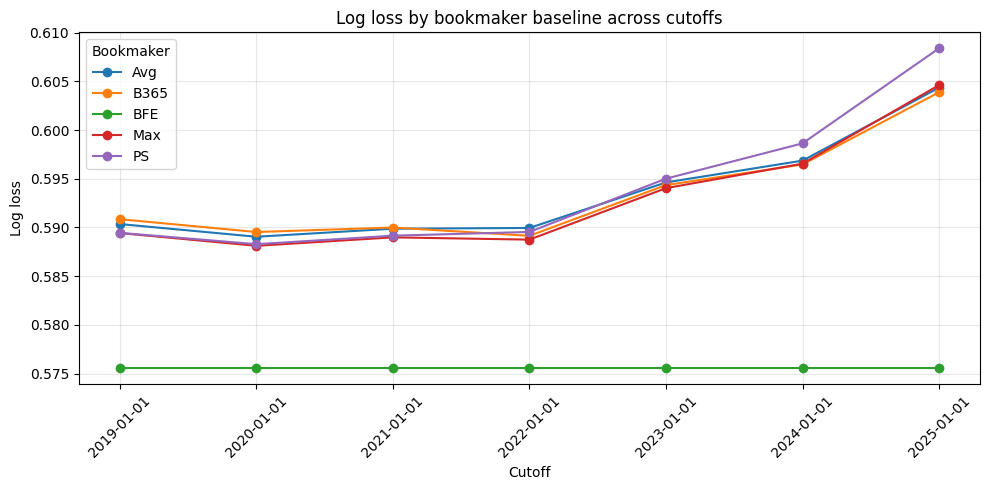

In [9]:
# Plot logloss by bookmaker and cutoff
pivot = all_results_df.pivot_table(index='cutoff', columns='bookmaker', values='logloss')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(ax=ax, marker='o')
ax.set_xlabel('Cutoff')
ax.set_ylabel('Log loss')
ax.set_title('Log loss by bookmaker baseline across cutoffs')
ax.legend(title='Bookmaker')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/bookmaker_baseline_logloss_by_cutoff.png', dpi=150)
plt.show()

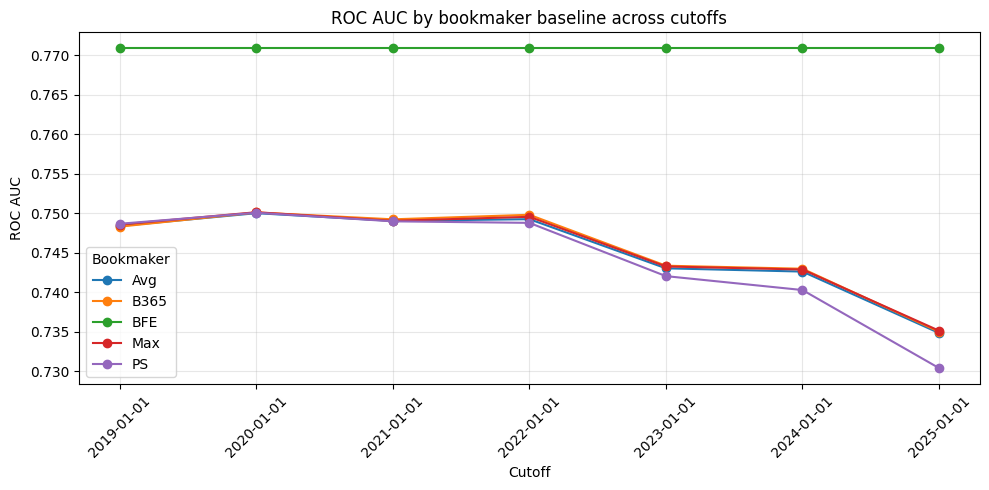

In [10]:
# Plot ROC AUC
pivot_auc = all_results_df.pivot_table(index='cutoff', columns='bookmaker', values='roc_auc')

fig, ax = plt.subplots(figsize=(10, 5))
pivot_auc.plot(ax=ax, marker='o')
ax.set_xlabel('Cutoff')
ax.set_ylabel('ROC AUC')
ax.set_title('ROC AUC by bookmaker baseline across cutoffs')
ax.legend(title='Bookmaker')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/bookmaker_baseline_auc_by_cutoff.png', dpi=150)
plt.show()

## 5. Выводы

Ожидаемые результаты:

1. **Max** (максимальные котировки) должен иметь лучший logloss/AUC, т.к. это "честные" котировки без маржи.

2. **PS** (Pinnacle) — один из лучших букмекеров с низкой маржой.

3. **B365** — выше маржа, может быть чуть хуже.

4. **Avg** — среднее по рынку, может быть хорошим baseline.

5. Разница между букмекерами должна быть небольшой (они все хорошо откалиброваны).